## DETECTION OF AI-GENERATED STEMS WITH HYBRID MIXTURES

Reproducing experiments from Section 5 & 6, with slight variations likely due to different random states.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
from scipy.special import expit
import joblib
import torch
from torchcodec.decoders import AudioDecoder
from IPython.display import display
import matplotlib.pyplot as plt

from hybrid_detection.databases.loader import musdb_demucs
from hybrid_detection.full_ai_exp.paths import FullAiExperimentPaths
from hybrid_detection.stem_ai_exp.paths import StemAiExperimentPaths
from hybrid_detection.stem_ai_exp.model import AiStemDetector
from hybrid_detection.core.data.fakeprint import FakePrint
from hybrid_detection.core.data.energy import BandSplitEnergy
from hybrid_detection.core.eval import tpr_fpr


/opt/miniconda3/envs/ismir2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load predictions from the "naive method" and compute evaluation metrics


In [2]:
naive_pred_dir = FullAiExperimentPaths().predictions_dir(db_predict='musdb_demucs_sources', db_train='fma', codec='encodec24', chunk_dur=None)

naive_pred_df = pd.read_parquet(naive_pred_dir)
naive_pred_df['method'] = 'naive'
naive_pred_df['database'] = 'musdb_demucs'

naive_eval_df = naive_pred_df \
    .groupby(['method', 'database', 'codec', 'chunk_dur', 'target_stem', 'target_gain_db'], dropna=False) \
    .apply(lambda x: tpr_fpr(x['label'], x['full_ai_score'], thr=0.5, as_pandas=True)) \
    .reset_index() \
    .groupby(['method', 'database', 'codec', 'chunk_dur', 'target_stem', 'target_gain_db'], dropna=False) \
    .agg({'tpr': [np.mean, np.std], 'fpr': [np.mean, np.std]})

display(naive_eval_df)


tpr  \
                                                                        mean   
method database     codec     chunk_dur target_stem target_gain_db             
naive  musdb_demucs encodec24 NaN       accomp      -12             0.990000   
                                                    -6              0.996667   
                                                     0              1.000000   
                                                     6              1.000000   
                                                     12             1.000000   
                                        vocals      -12             0.613333   
                                                    -6              0.756667   
                                                     0              0.876667   
                                                     6              0.950000   
                                                     12             0.960000   

                                                                         \
                                                                    std   
method database     codec     chunk_dur target_stem target_gain_db        
naive  musdb_demucs encodec24 NaN       accomp      -12             0.0   
                                                    -6              0.0   
                                                     0              0.0   
                                                     6              0.0   
                                                     12             0.0   
                                        vocals      -12             0.0   
                                                    -6              0.0   
                                                     0              0.0   
                                                     6              0.0   
                                                     12             0.0   

                                                                         fpr  \
                                                                        mean   
method database     codec     chunk_dur target_stem target_gain_db             
naive  musdb_demucs encodec24 NaN       accomp      -12             0.396667   
                                                    -6              0.306667   
                                                     0              0.200000   
                                                     6              0.133333   
                                                     12             0.063333   
                                        vocals      -12             0.483333   
                                                    -6              0.483333   
                                                     0              0.476667   
                                                     6              0.473333   
                                                     12             0.460000   

                                                                         
                                                                    std  
method database     codec     chunk_dur target_stem target_gain_db       
naive  musdb_demucs encodec24 NaN       accomp      -12             0.0  
                                                    -6              0.0  
                                                     0              0.0  
                                                     6              0.0  
                                                     12             0.0  
                                        vocals      -12             0.0  
                                                    -6              0.0  
                                                     0              0.0  
                                                     6              0.0  
                                                     12             0.0

## Load predictions from the "proposed method" and compute evaluation metrics

In [3]:
chunk_dur = [5, 2][1]  # Select manually here

proposed_pred_dfs = []

for db in ['musdb_oracle', 'musdb_demucs']:
    for target_stem in ['vocals', 'accomp']:
        for random_seed in [12, 31, 42, 54, 76, 98, 47, 77, 88, 666]:

            # Load chunk-level predictions
            pred_dir = StemAiExperimentPaths().model_dir(db, 'encodec24', target_stem, chunk_dur, random_seed)
            pred_df = pd.read_parquet(f'{pred_dir}/train_test_predictions.parquet', filters=[('train_set', '==', False)])
            pred_df['method'] = 'proposed'
            pred_df['database'] = db

            # Aggregate from chunk-level to track-level (drop mix silences, take mean prediction score)
            pred_df = pred_df[~pred_df['is_silence']] \
                .groupby(['method', 'database', 'codec', 'chunk_dur', 'seed', 'target_stem',
                          'track', 'mix_type', 'target_gain_db', 'label', 'train_set']) \
                .agg({'stem_ai_score': 'mean'}) \
                .reset_index()

            proposed_pred_dfs.append(pred_df)

proposed_pred_df = pd.concat(proposed_pred_dfs, ignore_index=True)

proposed_eval_df = proposed_pred_df \
    .groupby(['method', 'database', 'codec', 'chunk_dur', 'target_stem', 'target_gain_db', 'seed']) \
    .apply(lambda x: tpr_fpr(x['label'], x['stem_ai_score'], thr=0.5, as_pandas=True)) \
    .reset_index() \
    .groupby(['method', 'database', 'codec', 'chunk_dur', 'target_stem', 'target_gain_db']) \
    .agg({'tpr': [np.mean, np.std], 'fpr': [np.mean, np.std]})

display(proposed_eval_df)

tpr  \
                                                                          mean   
method   database     codec     chunk_dur target_stem target_gain_db             
proposed musdb_demucs encodec24 2.0       accomp      -12             0.987778   
                                                      -6              0.985556   
                                                       0              0.990000   
                                                       6              0.990000   
                                                       12             0.995556   
                                          vocals      -12             0.861111   
                                                      -6              0.900000   
                                                       0              0.934444   
                                                       6              0.946667   
                                                       12             0.955556   
         musdb_oracle encodec24 2.0       accomp      -12             0.973333   
                                                      -6              0.990000   
                                                       0              0.996667   
                                                       6              0.996667   
                                                       12             0.997778   
                                          vocals      -12             0.838889   
                                                      -6              0.888889   
                                                       0              0.930000   
                                                       6              0.947778   
                                                       12             0.952222   

                                                                                \
                                                                           std   
method   database     codec     chunk_dur target_stem target_gain_db             
proposed musdb_demucs encodec24 2.0       accomp      -12             0.012620   
                                                      -6              0.012222   
                                                       0              0.010482   
                                                       6              0.013563   
                                                       12             0.008889   
                                          vocals      -12             0.047726   
                                                      -6              0.039752   
                                                       0              0.030409   
                                                       6              0.024242   
                                                       12             0.016480   
         musdb_oracle encodec24 2.0       accomp      -12             0.011331   
                                                      -6              0.005984   
                                                       0              0.005092   
                                                       6              0.007115   
                                                       12             0.004444   
                                          vocals      -12             0.042528   
                                                      -6              0.039126   
                                                       0              0.034084   
                                                       6              0.031052   
                                                       12             0.028996   

                                                                           fpr  \
                                                                          mean   
method   database     codec     chunk_dur target_stem target_gain_db             
proposed musdb_demucs encodec24 2.0       accomp      -

## Display comparative evaluation

**Figure 2:** _TPR (top) and FPR (bottom) metrics for vocals (left) and accompaniment (right) AI-generated stem detections grouped over all mixing configurations, and as a function of the target gain (x-axis)._


Figure 2. TPR (top) and FPR (bottom) metrics for vocals (left) and accompaniment (right) AI-generated stem detections
grouped over all mixing configurations, and as a function of the target gain (x-axis).


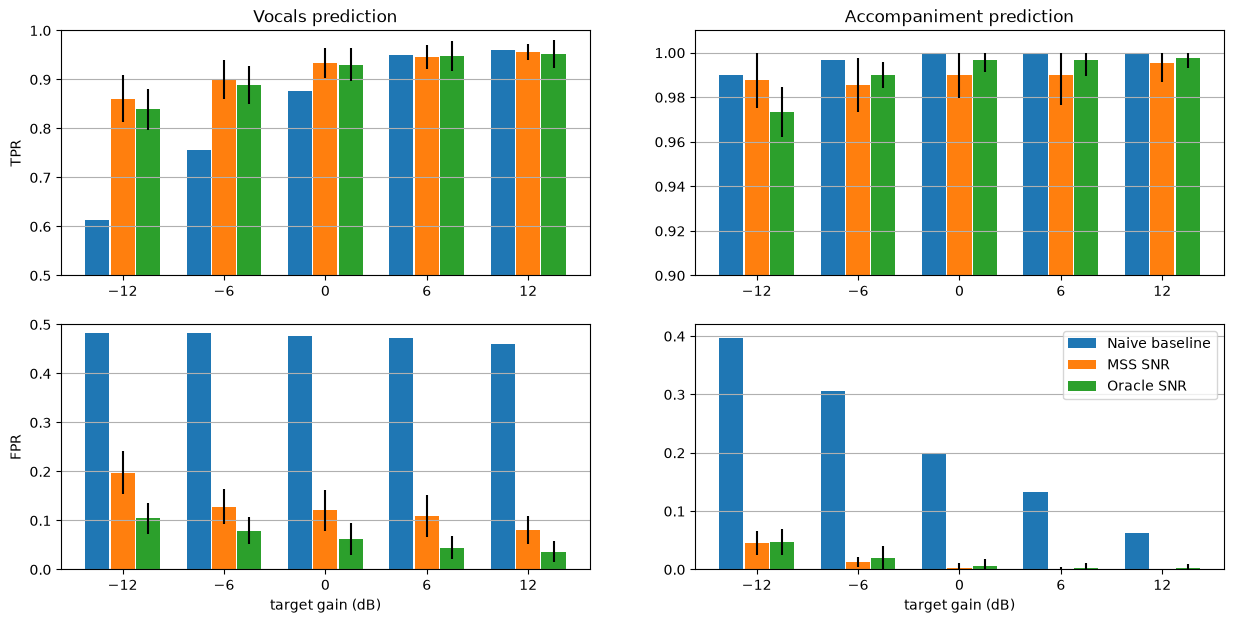

In [4]:
print('Figure 2. TPR (top) and FPR (bottom) metrics for vocals (left) and accompaniment (right) AI-generated stem detections\n'
      'grouped over all mixing configurations, and as a function of the target gain (x-axis).')

full_eval_df = pd.concat([naive_eval_df, proposed_eval_df], ignore_index=False)
full_eval_df.columns = ['_'.join(col) for col in full_eval_df.columns]

method_map_df = pd.DataFrame({'method_id': [0, 1, 2],
                              'method_xpos': [-1.5, 0, 1.5], # bar relative x position
                              'method': ['naive', 'proposed', 'proposed'],
                              'database': ['musdb_demucs', 'musdb_demucs', 'musdb_oracle']})

full_eval_df = method_map_df \
    .merge(full_eval_df.reset_index(drop=False), how='inner', on=['method', 'database']) \
    .sort_values(['method_id', 'target_gain_db'])

for metric in ['tpr', 'fpr']:  # clip error bars to [0, 1]
    mean_, std_ = full_eval_df[f'{metric}_mean'], full_eval_df[f'{metric}_std']
    full_eval_df[f'{metric}_errsup'] = np.clip(mean_ + std_, 0, 1) - mean_
    full_eval_df[f'{metric}_errinf'] = mean_ - np.clip(mean_ - std_, 0, 1)

full_eval_df = full_eval_df \
    .groupby(['target_stem', 'method_id']) \
    .agg({col: tuple for col in ['target_gain_db', 'method_xpos', 'tpr_mean', 'tpr_errinf', 'tpr_errsup', 'fpr_mean', 'fpr_errinf', 'fpr_errsup']}) \
    .reset_index()

labels = ['Naive baseline', 'MSS SNR', 'Oracle SNR']
colors = ['tab:blue', 'tab:orange', 'tab:green']

plt.figure(figsize=(15, 7))

for (fig_id, target_stem, metric, title, x_label, y_label, y_lim, labels) in [
    (1, 'vocals', 'tpr', 'Vocals prediction', '', 'TPR', (0.5, 1), None),
    (2, 'accomp', 'tpr', 'Accompaniment prediction', '', '', (0.9, 1.01), None),
    (3, 'vocals', 'fpr', '', 'target gain (dB)', 'FPR', (0, 0.5), None),
    (4, 'accomp', 'fpr', '', 'target gain (dB)', '', (0, 0.42), tuple(labels))
]:
    stem_eval = full_eval_df[full_eval_df['target_stem'] == target_stem].sort_values('method_id')

    snr_grid = np.unique(stem_eval['target_gain_db'].values)[0]
    x_axis = (np.vstack(stem_eval['target_gain_db'].values) + np.vstack(stem_eval['method_xpos'].values)).T.reshape(-1)
    bar_width = np.min(np.diff(x_axis)) * 0.95

    mean_metric = np.vstack(stem_eval[f'{metric}_mean'].values).T.reshape(-1)
    err_inf = np.vstack(stem_eval[f'{metric}_errinf'].values).T.reshape(-1)
    err_sup = np.vstack(stem_eval[f'{metric}_errsup'].values).T.reshape(-1)

    plt.subplot(2, 2, fig_id)
    bars = plt.bar(x_axis, mean_metric, width=bar_width, color=colors, yerr=[err_inf, err_sup])
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.xticks(snr_grid)
    plt.ylim(y_lim)
    plt.grid(axis='y')
    if labels:
        plt.legend(bars[:len(labels)], labels)

plt.show()


## Confusion matrices

Reproducing:
- **Figure 1**: _Confusion matrices for the naive stem detectors for all mixing cases with target gain 0dB._
- **Figure 3**: _Confusion matrices for the proposed AI-generated vocals detector for a target gain of 0dB. Influence of MSS over Oracle SNR estimator._


In [5]:
print('Figure 1. Confusion matrices for the naive stem detectors for all mixing cases with target gain 0dB.')

naive_pred_df['pred'] = naive_pred_df['full_ai_score'].apply(lambda x: int(x >= 0.5))

naive_confusion_df = naive_pred_df[naive_pred_df['target_gain_db'] == 0] \
    .groupby(['method', 'database', 'target_gain_db', 'target_stem', 'mix_type', 'pred'], dropna=False) \
    .size() \
    .rename('n_samples') \
    .reset_index(drop=False) \
    .pivot(index=['method', 'database', 'target_gain_db', 'target_stem', 'mix_type'], columns='pred', values='n_samples') \
    .fillna(0). \
    sort_index(level=['target_stem', 'mix_type'], ascending=False)

n_samples = naive_confusion_df.sum(axis=1)
for pred in [0, 1]:  # from TP, FP, ... to TPR, FPR, ... in %
    naive_confusion_df[pred] = np.round(100 * naive_confusion_df[pred] / n_samples, decimals=1)

display(naive_confusion_df)

print('\nFigure 3: Confusion matrices for the proposed AI-generated vocals detector for a target gain of 0dB.\n'
      'Influence of MSS over Oracle SNR estimator.')

proposed_pred_df['pred'] = proposed_pred_df['stem_ai_score'].apply(lambda x: int(x >= 0.5))

proposed_confusion_df = proposed_pred_df[(proposed_pred_df['target_gain_db'] == 0) & (proposed_pred_df['target_stem'] == 'vocals')] \
    .groupby(['method', 'database', 'target_gain_db', 'target_stem', 'mix_type', 'pred'], dropna=False) \
    .size() \
    .rename('n_samples') \
    .reset_index(drop=False) \
    .pivot(index=['method', 'database', 'target_gain_db', 'target_stem', 'mix_type'], columns='pred', values='n_samples') \
    .fillna(0). \
    sort_index(level=['database', 'mix_type'], ascending=False)

n_samples = proposed_confusion_df.sum(axis=1)
for pred in [0, 1]:  # from TP, FP, ... to TPR, FPR, ... in %
    proposed_confusion_df[pred] = np.round(100 * proposed_confusion_df[pred] / n_samples, decimals=1)

display(proposed_confusion_df)


Figure 1. Confusion matrices for the naive stem detectors for all mixing cases with target gain 0dB.


pred                                                         0      1
method database     target_gain_db target_stem mix_type              
naive  musdb_demucs 0              vocals      vr_ar     100.0    0.0
                                               vr_ag       4.7   95.3
                                               vg_ar      23.3   76.7
                                               vg_ag       1.3   98.7
                                   accomp      vr_ar     100.0    0.0
                                               vr_ag       0.0  100.0
                                               vg_ar      60.0   40.0
                                               vg_ag       0.0  100.0


Figure 3: Confusion matrices for the proposed AI-generated vocals detector for a target gain of 0dB.
Influence of MSS over Oracle SNR estimator.


pred                                                          0     1
method   database     target_gain_db target_stem mix_type            
proposed musdb_oracle 0              vocals      vr_ar     99.1   0.9
                                                 vr_ag     88.4  11.6
                                                 vg_ar      9.6  90.4
                                                 vg_ag      4.4  95.6
         musdb_demucs 0              vocals      vr_ar     99.3   0.7
                                                 vr_ag     76.4  23.6
                                                 vg_ar     10.0  90.0
                                                 vg_ag      3.1  96.9

## Proposed approach, Section 6.4. Qualitative analysis

Reproducing **Figure 4:** _Trained posteriors for the generated vocals (left) and accompaniment (right) detection models.
X-axis:logit-transformed fake score; how strongly the local detector predicts the mix as fake.
Y-axis: SNR in dB; how loud the target stem is relative to the complementary stem._

Figure 4. Trained posteriors for the generated vocals (left) and accompaniment (right) detection models.
X-axis: logit-transformed fake score; how strongly the local detector predicts the mix as fake.
Y-axis: SNR in dB; how loud the target stem is relative to the complementary stem.



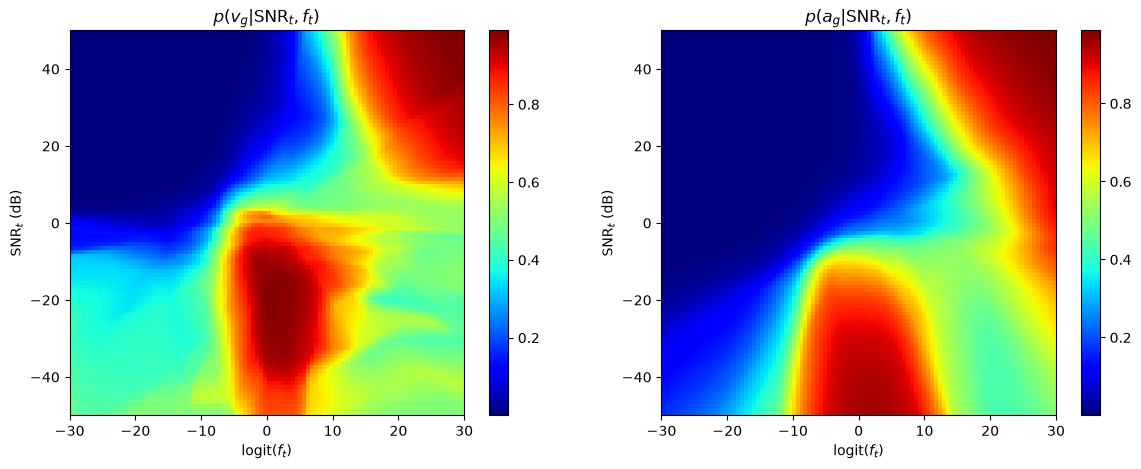

In [6]:
# Select manually here
db = ['musdb_oracle', 'musdb_demucs'][0]
chunk_dur = [5, 2][0]

# Load vocals & accompaniment detectors
vocals_model_dir = StemAiExperimentPaths().model_dir(db, 'encodec24', 'vocals', chunk_dur, 42, single_snr_band=True)
accomp_model_dir = StemAiExperimentPaths().model_dir(db, 'encodec24', 'accomp', chunk_dur, 42, single_snr_band=True)

vocals_model = AiStemDetector.load_from_checkpoint_dir(vocals_model_dir)
accomp_model = AiStemDetector.load_from_checkpoint_dir(accomp_model_dir)

# Prepare input grid for evaluating the posterior probabilities
logit_f_grid = np.linspace(-30, 30, 100, dtype=np.float32)
SNR_grid = np.linspace(-50, 50, 100, dtype=np.float32)
inputs_grid = np.meshgrid(logit_f_grid, SNR_grid)
inputs_grid = np.vstack((inputs_grid[0].reshape(-1), inputs_grid[1].reshape(-1))).T

# Run models
with torch.no_grad():
    vocals_posterior = vocals_model(torch.Tensor(inputs_grid)).numpy().reshape((len(SNR_grid), len(logit_f_grid)))
    accomp_posterior = accomp_model(torch.Tensor(inputs_grid)).numpy().reshape((len(SNR_grid), len(logit_f_grid)))

# Display
print('Figure 4. Trained posteriors for the generated vocals (left) and accompaniment (right) detection models.\n'
      'X-axis: logit-transformed fake score; how strongly the local detector predicts the mix as fake.\n'
      'Y-axis: SNR in dB; how loud the target stem is relative to the complementary stem.\n')

imshow_kwargs = {'aspect': 'auto', 'origin': 'lower', 'cmap': 'jet', 'interpolation': 'none',
                 'extent': (logit_f_grid[0], logit_f_grid[-1], SNR_grid[0], SNR_grid[-1])}

plt.figure(figsize=(14, 5))
plt.subplot(121)
plt.imshow(vocals_posterior, **imshow_kwargs)
plt.colorbar()
plt.title('$p(v_{g} | $SNR$_{t}, f_{t})$')
plt.ylabel('SNR$_{t}$ (dB)')
plt.xlabel('logit$(f_{t})$')
plt.subplot(122)
plt.imshow(accomp_posterior, **imshow_kwargs)
plt.colorbar()
plt.title('$p(a_{g} | $SNR$_{t}, f_{t})$')
plt.ylabel('SNR$_{t}$ (dB)')
plt.xlabel('logit$(f_{t})$')
plt.show()


# Sample illustration - Local predictions

Reproducing **Figure 5:** _Illustration of the AI-generated stem detection for a hybrid track with generated vocals (vg + ar) at 0dB.
(a) Waveforms of mix, and sources obtained through MSS.
(b) Local detection on 2-sec chunks, run independently on the mix and on both MSS extracted sources, according
to the naive approach from Section 5, revealing that artifacts from the vocals have spread to the separated accompaniment.
(c) Output of the local stem-specific detectors p(vg |ft, {SNR_bt , b in B}) and p(ag |ft, {SNR_bt , b in B})
from Section 6._


Figure 5: Illustration of the AI-generated stem detection for a hybrid track with generated vocals (vg + ar ) at 0dB.
(a) Waveforms of mix, and sources obtained through MSS.
(b) Local detection on 2-sec chunks, run independently on the mix and on both MSS extracted sources, according 
to the naive approach from Section 5, revealing that artifacts from the vocals have spread to the separated accompaniment.
(c) Output of the local stem-specific detectors p(vg |ft, {SNR_bt , b in B}) and p(ag |ft, {SNR_bt , b in B}) from Section 6.


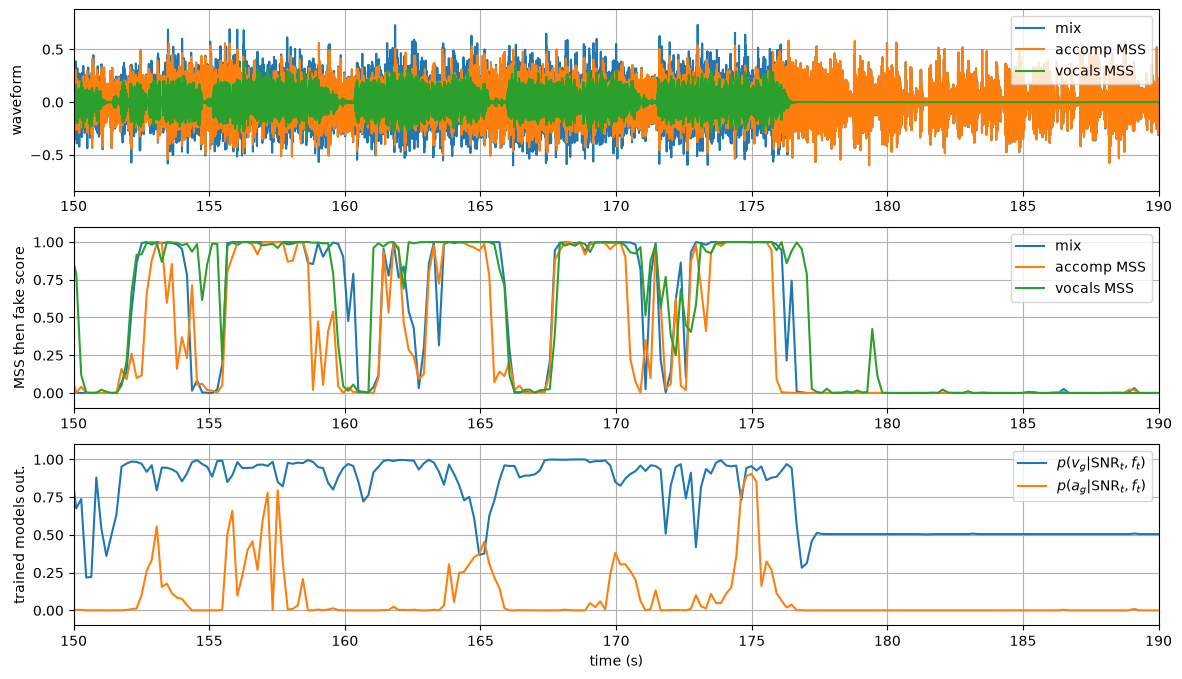

In [7]:
track, xlim = 'Young Griffo - Pennies', [150, 190]
mix_type = 'vg_ar'
vocals_gain_db = 0

chunk_dur = 2
chunk_ov = 0.9

# -- Load audio files

database_df = musdb_demucs()
database_df = database_df[(database_df['track'] == track) &
                          (database_df['vocals_gain_db'] == vocals_gain_db) &
                          (database_df['mix_type'] == mix_type)]

sr = 44100
mix_sig = AudioDecoder(database_df['mix_path'].tolist()[0]).get_all_samples().data
vocals_sig = AudioDecoder(database_df['vocals_path'].tolist()[0]).get_all_samples().data
accomp_sig = AudioDecoder(database_df['accomp_path'].tolist()[0]).get_all_samples().data

# -- Compute local full AI detection

fakeprint_tf = FakePrint()

mix_fakeprints = fakeprint_tf.compute_from_waveform(mix_sig.clone(), chunk_dur, chunk_ov)
vocals_fakeprints = fakeprint_tf.compute_from_waveform(vocals_sig.clone(), chunk_dur, chunk_ov)
accomp_fakeprints = fakeprint_tf.compute_from_waveform(accomp_sig.clone(), chunk_dur, chunk_ov)

full_ai_model_dir = FullAiExperimentPaths.model_dir(db='fma', codec='encodec24', chunk_dur=2)
full_ai_model = joblib.load(f'{full_ai_model_dir}/model.pkl')

mix_full_ai_logit_score = full_ai_model.decision_function(mix_fakeprints)
vocals_full_ai_logit_score = full_ai_model.decision_function(vocals_fakeprints)
accomp_full_ai_logit_score = full_ai_model.decision_function(accomp_fakeprints)

chunk_t_axis = fakeprint_tf.stft_chunker.t_axis_chunks(chunk_dur, chunk_ov, len(mix_full_ai_logit_score))

# -- Compute local stem AI detection (proposed approach)

energy_tf = BandSplitEnergy()
vocals_energy_tf = energy_tf.compute_from_waveform(vocals_sig.clone(), chunk_dur, chunk_ov)
accomp_energy_tf = energy_tf.compute_from_waveform(accomp_sig.clone(), chunk_dur, chunk_ov)

vocals_snr_tf = 10*np.log10(np.clip(vocals_energy_tf, 1e-8, None)) - 10*np.log10(np.clip(accomp_energy_tf, 1e-8, None))

# Make sure to select a model that has not seen this track in the train set
valid_split_seeds = proposed_pred_df[~proposed_pred_df['train_set'] & (proposed_pred_df['track'] == track)]['seed'].unique()

vocals_ai_model_dir = StemAiExperimentPaths.model_dir(db="musdb_demucs", codec='encodec24', stem='vocals', chunk_dur=chunk_dur, random_seed=valid_split_seeds[0])
accomp_ai_model_dir = StemAiExperimentPaths.model_dir(db="musdb_demucs", codec='encodec24', stem='accomp', chunk_dur=chunk_dur, random_seed=valid_split_seeds[0])

vocals_ai_model = AiStemDetector.load_from_checkpoint_dir(vocals_ai_model_dir).eval()
accomp_ai_model = AiStemDetector.load_from_checkpoint_dir(accomp_ai_model_dir).eval()

with torch.no_grad():
    vocals_stem_ai_score = vocals_ai_model(torch.Tensor(np.hstack([mix_full_ai_logit_score[:, None], vocals_snr_tf])))
    accomp_stem_ai_score = accomp_ai_model(torch.Tensor(np.hstack([mix_full_ai_logit_score[:, None], -vocals_snr_tf])))

# -- Display

print('Figure 5: Illustration of the AI-generated stem detection for a hybrid track with generated vocals (vg + ar ) at 0dB.\n'
      '(a) Waveforms of mix, and sources obtained through MSS.\n'
      '(b) Local detection on 2-sec chunks, run independently on the mix and on both MSS extracted sources, according \n'
      'to the naive approach from Section 5, revealing that artifacts from the vocals have spread to the separated accompaniment.\n'
      '(c) Output of the local stem-specific detectors p(vg |ft, {SNR_bt , b in B}) and p(ag |ft, {SNR_bt , b in B}) from Section 6.')

plt.figure(figsize=(14, 8))

plt.subplot(311)
t_grid = np.arange(mix_sig.shape[-1]) / sr
plt.plot(t_grid[::100], mix_sig.mean(axis=0)[::100], label='mix')
plt.plot(t_grid[::100], accomp_sig.mean(axis=0)[::100], label='accomp MSS')
plt.plot(t_grid[::100], vocals_sig.mean(axis=0)[::100], label='vocals MSS')
plt.xlim(xlim)
plt.grid()
plt.legend(loc='upper right')
plt.ylabel(f'waveform')

plt.subplot(312)
plt.plot(chunk_t_axis, expit(mix_full_ai_logit_score), label='mix')
plt.plot(chunk_t_axis, expit(accomp_full_ai_logit_score), label='accomp MSS')
plt.plot(chunk_t_axis, expit(vocals_full_ai_logit_score), label='vocals MSS')
plt.legend(loc='upper right')
plt.grid()
plt.xlim(xlim)
plt.ylim([-0.1, 1.1])
plt.ylabel(f'MSS then fake score')

plt.subplot(313)
plt.plot(chunk_t_axis, vocals_stem_ai_score, label='$p(v_{g} | $SNR$_{t}, f_{t})$')
plt.plot(chunk_t_axis, accomp_stem_ai_score, label='$p(a_{g} | $SNR$_{t}, f_{t})$')
plt.legend(loc='upper right')
plt.grid()
plt.xlim(xlim)
plt.ylim([-0.1, 1.1])
plt.ylabel(f'trained models out.')
plt.xlabel(f'time (s)')

plt.show()